## Build a basic chatbot with Langgraph(Graph API)

In [18]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:

class State(TypedDict):
    #TypedDict is a way in Python to specify the structure of a dictionary with types.
    #State is a dictionary-like object with a key "messages" that stores a list of messages.
    #Syntax: Annotated[Type, Metadata]
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]
    

In [3]:

import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="openai/gpt-oss-120b")

In [5]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10960c750>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x109a74d10>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
llm=init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x109a77750>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x109a782d0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:

## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}
#invoke() is the method that sends input to the model and returns the output.
#Here, it is being passed the entire message history, i.e., state["messages"].
#Effectively, the model sees all previous messages to generate the next response
#The function returns a dictionary with a single key "messages".

In [8]:

graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

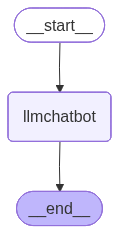

In [9]:

## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:

response=graph.invoke({"messages":"Hi"})

In [11]:

response["messages"][-1].content

'Hello! How can I help you today?'

In [12]:
# for event in graph.stream({"messages":"Hi how are you"}):
#     for value in event.values():
#         print(value)
        
for event in graph.stream({"messages":"Hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hey there! I'm doing great, thanks for asking. How can I help you today?


## Chatbot With Tool

In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("What is langraph")

{'query': 'What is langraph',
 'response_time': 0.61,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by [LangChain](https://www.ibm.com/think/topics/langchain), is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an [AI agent workflow](https://www.ibm.com/think/topics/ai-agents). The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the [AI workflow](https://www.ibm.com/think/topics/ai-workflow) as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this s

In [14]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [15]:
tools = [tool,multiply]

In [19]:
llm_with_tool = llm.bind_tools(tools)

In [20]:
llm_with_tool

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x109a77750>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x109a782d0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search

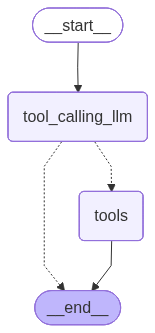

In [21]:

## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
response = graph.invoke({"messages":"what is the recent AI news"})


In [23]:
# response["messages"][-1]
response["messages"][-1].content

'{"query": "latest AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.jdsupra.com/legalnews/ai-today-in-5-march-5-2026-the-ai-s-02926/", "title": "AI Today in 5: March 5, 2026, The AI ‘s Biggest Test Edition | Thomas Fox - Compliance Evangelist - JD Supra", "score": 0.8884594, "published_date": "Thu, 05 Mar 2026 20:07:02 GMT", "content": "Send;)Report\\n\\n### Latest Posts\\n\\n   AI Today in 5: March 5, 2026, The AI ‘s Biggest Test EditionVideo \\n   Daily Compliance News: March 5, 2026, The DOJ and State Bars EditionVideo \\n   AI Today in 5: March 4, 2026, The AI Content Explosion EditionVideo \\n   Great Women in Compliance: Resilience is a Muscle You Can BuildVideo \\n   Compliance into the Weeds: SDNY’s New Declination Policy: Crime Categories, Cooperation, and Compliance ImplicationsVideo \\n\\nSee more »\\n\\nOther MultiMedia by Thomas Fox - Compliance Evangelist\\n\\n   Image 2Image 3\\nDaily Compliance News: March 

In [24]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_a2ecce05-81f5-4643-8a57-84a8b9c303b3)
 Call ID: fc_a2ecce05-81f5-4643-8a57-84a8b9c303b3
  Args:
    query: latest AI news March 2026
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.jdsupra.com/legalnews/ai-today-in-5-march-5-2026-the-ai-s-02926/", "title": "AI Today in 5: March 5, 2026, The AI ‘s Biggest Test Edition | Thomas Fox - Compliance Evangelist - JD Supra", "score": 0.8884594, "published_date": "Thu, 05 Mar 2026 20:07:02 GMT", "content": "Send;)Report\n\n### Latest Posts\n\n   AI Today in 5: March 5, 2026, The AI ‘

In [25]:
response = graph.invoke({"messages":"what is 2 multipled by 3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multipled by 3
================================== Ai Message ==================================

2 × 3 = 6.


In [26]:
response = graph.invoke({"messages":"what is 2 multiplied by 3 and then multiply 10 "})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 3 and then multiply 10 
================================== Ai Message ==================================

\(2 \times 3 = 6\)

\(6 \times 10 = 60\)

So the result is **60**.


In [27]:
response = graph.invoke({"messages":"what is the recent AI news and 5 multiply by 2"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news and 5 multiply by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_8dbf6021-24b0-4ba7-95ff-40249884d7e1)
 Call ID: fc_8dbf6021-24b0-4ba7-95ff-40249884d7e1
  Args:
    query: latest AI news March 2026
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.euronews.com/video/2026/03/06/watch-the-video-how-is-artificial-intelligence-used-in-warfare-right-now", "title": "Video. Watch: How is artificial intelligence used in warfare right now?", "content": "Facebook\nTwitter\nFlipboard\nInstagram\nLinkedin\n\nLatest news bulletin | March 7th, 2026 – Midday\nPatrons stand outside and view damage to

### React Agent Architecture

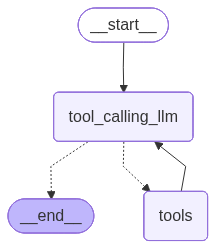

In [28]:
 
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")


## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
response = graph.invoke({"messages":"what is the recent AI news and 5 multiply by 2"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news and 5 multiply by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_725b4d86-0e4b-4409-8c5d-319e62868740)
 Call ID: fc_725b4d86-0e4b-4409-8c5d-319e62868740
  Args:
    query: latest AI news March 2026
    search_depth: fast
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://opentools.ai/news/ai-in-2024-a-year-of-groundbreaking-releases-and-shifting-paradigms/tech-innovations", "title": "Latest AI News: March 5, 2026", "content": "Latest AI News: March 5, 2026\n\n# Latest AI News: March 5, 2026. Stay informed with our daily curated artificial intelligence news and insights. We bring you the most important updates in AI, m

In [30]:
response = graph.invoke({"messages":"what is the recent AI news and 5 multiply by 2 and add 4 and 3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news and 5 multiply by 2 and add 4 and 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_1878dfee-81c9-45f5-a82f-3c177e40b4f1)
 Call ID: fc_1878dfee-81c9-45f5-a82f-3c177e40b4f1
  Args:
    query: latest AI news March 2026
    search_depth: fast
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://opentools.ai/news/ai-in-2024-a-year-of-groundbreaking-releases-and-shifting-paradigms/tech-innovations", "title": "Latest AI News: March 5, 2026", "content": "Latest AI News: March 5, 2026\n\n# Latest AI News: March 5, 2026. Stay informed with our daily curated artificial intelligence news and insights. We bring you the most importan

### Adding memory in Agentic Graph

In [31]:
response = graph.invoke({"messages":"Hello my name is Saara"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Saara
================================== Ai Message ==================================

Hi Saara! Nice to meet you. How can I help you today?


In [32]:
response = graph.invoke({"messages":"What is my name?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don’t have any information about your name. If you’d like me to address you by a particular name, just let me know!


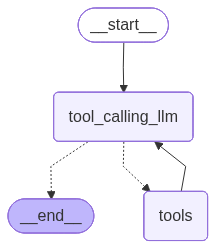

In [33]:
 
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")


## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
#If we want to use this specific memory for a previous interaction
# or if we want the context of the previous interaction, first of all we need to create
# a thread id.Because it will be related to one specific session
config = {"configurable": {"thread_id": "1"}}

In [35]:
response = graph.invoke({"messages": "Hi, my name is Saara"}, config=config)
response

{'messages': [HumanMessage(content='Hi, my name is Saara', additional_kwargs={}, response_metadata={}, id='af23b6eb-14bc-4b6d-8bd7-a045ffe9a7dd'),
  AIMessage(content='Hi Saara! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi, my name is Saara". Likely wants a greeting. Should respond friendly, perhaps ask how can I help.'}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 349, 'total_tokens': 406, 'completion_time': 0.13045232, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.280120077, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.045443822, 'total_time': 0.410572397}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd1bb-5eaf-7d42-8fa8-acf3971f0a87-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_to

In [38]:
response = graph.invoke({"messages": "What's my name"}, config=config)
print(response["messages"][-1].content)

Your name is Saara.


In [39]:
response = graph.invoke({"messages": "Hey, do you remember my name?"}, config=config)
print(response["messages"][-1].content)

Absolutely—I’ve got it! Your name is Saara. 😊 How can I help you today?


In [ ]:

config = {"configurable": {"thread_id": "2"}}
response = graph.invoke({"messages": "Hey, do you remember my name?"}, config=config)
print(response["messages"][-1].content)
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": "Hey, do you remember my name?"}, config=config)
print(response["messages"][-1].content)

I’m not sure what name you’d like me to use—could you let me know?
Yes, I remember—your name is Saara! What would you like to talk about or work on today?
